<b>Team H</b>

Team Members: 

Random Forest Model: Adinolfe Evan C (eca77)

Naive Bayes Model: Chuang, Ho-Chen (hc999)

Neural Network Model: Karingula Hitesh (hk861)

Logistic Regression Model: Patel Krish B (kbp101)






Data Used: Sentiment140 (1.6 Million Tweets)

Dataset Link: Kaggle - Twitter Sentiment Analysis: https://www.kaggle.com/code/paoloripamonti/twitter-sentiment-analysis/data

Random Forest: Adinolfe Evan C (eca77)

In [1]:
#Using AI
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment','id','date','query','user','text'],
    on_bad_lines='skip'
)

df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

df.dropna(subset=['text', 'sentiment'], inplace=True)

vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    max_df=0.5,
    min_df=5,
    stop_words='english'
)

X = vectorizer.fit_transform(df['text'])

X_train, X_test, y_train, y_test=train_test_split(
    X, df['sentiment'],
    train_size=0.1,
    test_size=0.02,
    random_state=20,
    stratify=df['sentiment']
)

In [2]:
display(df)

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,1,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,1,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,1,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,1,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...



Random Forest Accuracy: 0.7304

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.66      0.71     16000
    Positive       0.70      0.80      0.75     16000

    accuracy                           0.73     32000
   macro avg       0.73      0.73      0.73     32000
weighted avg       0.73      0.73      0.73     32000



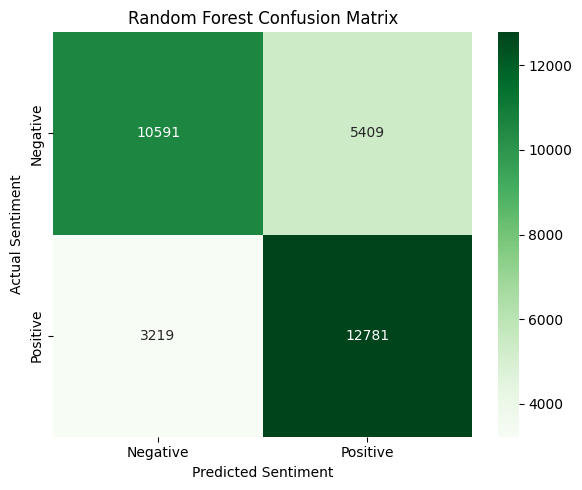

In [3]:
#Using AI
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=15,
    min_samples_leaf= 5,
    random_state =42
)

rf.fit(X_train, y_train)

predict_rf=rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, predict_rf)
report_rf= classification_report(y_test, predict_rf,target_names =['Negative', 'Positive'])
cm_rf = confusion_matrix(y_test, predict_rf)

print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(report_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

Naive Bayes Model: Chuang, Ho-Chen (hc999)

In [4]:
#Using AI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

In [5]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=50000, stop_words='english')),
    ('clf', MultinomialNB())
])

In [6]:
#Using AI
df_sample = df.sample(200000) 
X_train, X_test, y_train, y_test = train_test_split(df_sample['text'], df_sample['sentiment'], test_size=0.2)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76     20006
           4       0.76      0.76      0.76     19994

    accuracy                           0.76     40000
   macro avg       0.76      0.76      0.76     40000
weighted avg       0.76      0.76      0.76     40000



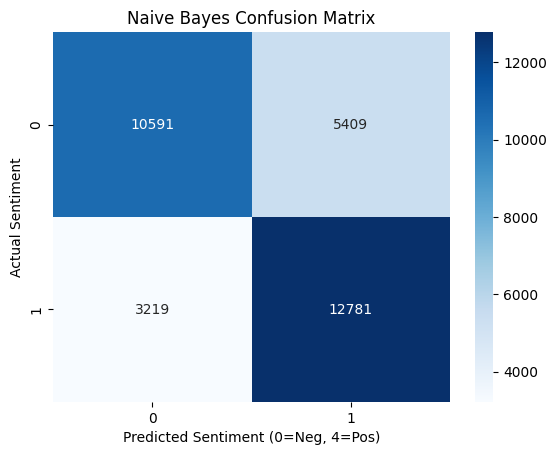

In [36]:
#Using AI
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Sentiment (0=Neg, 4=Pos)')
plt.ylabel('Actual Sentiment')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

Neural Network Model: Karingula Hitesh (hk861)

In [39]:
#Using AI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
     

In [9]:
df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text'],
    on_bad_lines='skip'
)

df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

df.dropna(subset=['text', 'sentiment'], inplace=True)

display(df)

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,1,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,1,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,1,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,1,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [10]:
df_sample = df.sample(200000, random_state=42)

display(df_sample)

,sentiment,id,date,query,user,text
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem
...,...,...,...,...,...,...
1369799,1,2050886849,Fri Jun 05 19:28:21 PDT 2009,NO_QUERY,jacobdesmit,@pauseven not that pool. but i will indeed hav...
43554,0,1676557139,Fri May 01 22:24:35 PDT 2009,NO_QUERY,_free_fall_,@gerardway
559176,0,2204916250,Wed Jun 17 03:28:29 PDT 2009,NO_QUERY,FrancescaDVC,so ragin its rainin out rain rain go away
1287524,1,2002375219,Tue Jun 02 04:01:39 PDT 2009,NO_QUERY,mathaba_forum,@dwaynekerr great one


In [11]:
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    max_df=0.5,
    min_df=5,
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(df_sample['text'])

y = df_sample['sentiment']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.1,
    test_size=0.02,
    random_state=20,
    stratify=y
)

In [ ]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(5000,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
history = model.fit(
    X_train.toarray(),
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6869 - loss: 0.5832 - val_accuracy: 0.7358 - val_loss: 0.5264
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7914 - loss: 0.4478 - val_accuracy: 0.7335 - val_loss: 0.5438
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8402 - loss: 0.3683 - val_accuracy: 0.7255 - val_loss: 0.6128
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8806 - loss: 0.2875 - val_accuracy: 0.7175 - val_loss: 0.6715
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9199 - loss: 0.2019 - val_accuracy: 0.7070 - val_loss: 0.8578


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step


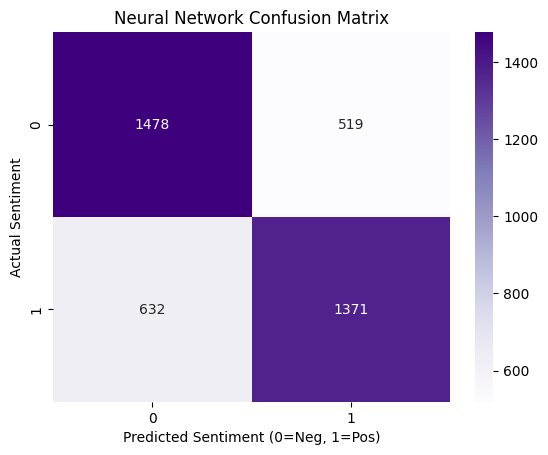

In [48]:

y_pred_probs = model.predict(X_test.toarray())
predictions = (y_pred_probs > 0.5).astype("int32")
cm_rf = confusion_matrix(y_test, predictions)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')

plt.xlabel('Predicted Sentiment (0=Neg, 1=Pos)')
plt.ylabel('Actual Sentiment')

plt.title('Neural Network Confusion Matrix')

plt.show()

Logistic Regression: Patel Krish B (kbp101)

In [52]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings('ignore')

In [55]:
col_names = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=col_names
)

df = df[['sentiment', 'text']]
df['sentiment'] = df['sentiment'].replace(4, 1)

print(f'Dataset shape: {df.shape}')
print(df['sentiment'].value_counts())

Dataset shape: (1600000, 2)
sentiment
0    800000
1    800000
Name: count, dtype: int64


In [56]:
sample_size = 50000

neg = df[df['sentiment'] == 0].sample(sample_size, random_state=42)
pos = df[df['sentiment'] == 1].sample(sample_size, random_state=42)

df_sample = pd.concat([neg, pos]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Sample size: {len(df_sample)} tweets')
print(df_sample['sentiment'].value_counts())

Sample size: 100000 tweets
sentiment
1    50000
0    50000
Name: count, dtype: int64


In [57]:
STOP_WORDS = set(stopwords.words('english'))

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in STOP_WORDS]
    return ' '.join(words)

df_sample['clean_text'] = df_sample['text'].apply(clean_tweet)

print('BEFORE:', df_sample['text'].iloc[0])
print('AFTER: ', df_sample['clean_text'].iloc[0])

BEFORE: @stargazer60 that's awesome 
AFTER:  thats awesome


In [58]:
X = df_sample['clean_text']
y = df_sample['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Training matrix shape: {X_train_tfidf.shape}')
print(f'Testing matrix shape:  {X_test_tfidf.shape}')

Training matrix shape: (80000, 50000)
Testing matrix shape:  (20000, 50000)


In [59]:
lr_model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)
print('Model trained.')

Model trained.


In [60]:
y_pred = lr_model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Test Accuracy: 0.7713 (77.13%)

              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77     10000
    Positive       0.76      0.78      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



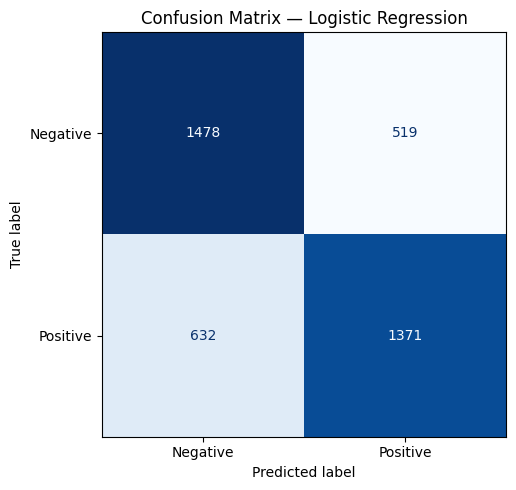

In [62]:

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f'Best C: {grid_search.best_params_["C"]}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

results_df = pd.DataFrame(grid_search.cv_results_)[['param_C', 'mean_test_score', 'std_test_score']]
results_df.columns = ['C', 'Mean Accuracy', 'Std Dev']
print(results_df.to_string(index=False))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: 1
Best CV accuracy: 0.7685
     C  Mean Accuracy  Std Dev
  0.01       0.732712 0.003434
  0.10       0.751850 0.001476
  1.00       0.768525 0.002035
 10.00       0.756550 0.002006
100.00       0.727662 0.001623


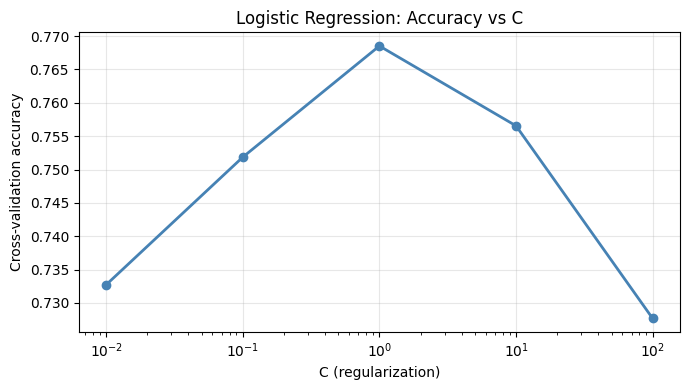

In [64]:
c_values = param_grid['C']
mean_scores = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(7, 4))
plt.semilogx(c_values, mean_scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('C (regularization)')
plt.ylabel('Cross-validation accuracy')
plt.title('Logistic Regression: Accuracy vs C')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cv_regularization_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_tfidf)

best_acc = accuracy_score(y_test, y_pred_best)
print(f'Final Accuracy (C={grid_search.best_params_["C"]}): {best_acc:.4f} ({best_acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive']))

Final Accuracy (C=1): 0.7713 (77.13%)

              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77     10000
    Positive       0.76      0.78      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



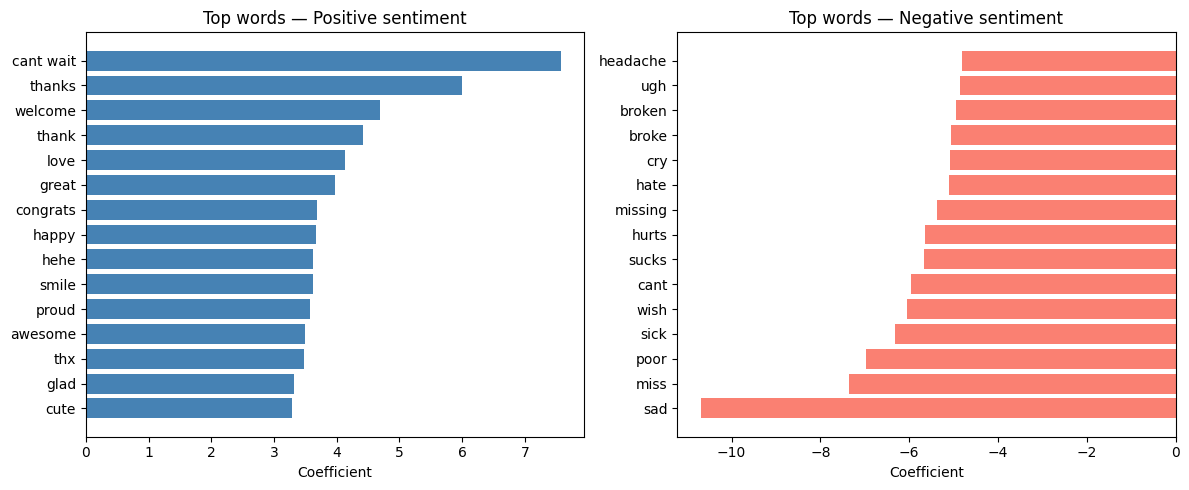

In [66]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = best_model.coef_[0]

top_n = 15
top_pos_idx = np.argsort(coefficients)[-top_n:][::-1]
top_neg_idx = np.argsort(coefficients)[:top_n]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.barh(feature_names[top_pos_idx][::-1], coefficients[top_pos_idx][::-1], color='steelblue')
ax1.set_title('Top words — Positive sentiment')
ax1.set_xlabel('Coefficient')

ax2.barh(feature_names[top_neg_idx], coefficients[top_neg_idx], color='salmon')
ax2.set_title('Top words — Negative sentiment')
ax2.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('top_words_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
def predict_sentiment(tweet_text):
    cleaned = clean_tweet(tweet_text)
    vectorized = tfidf.transform([cleaned])
    prediction = best_model.predict(vectorized)[0]
    probability = best_model.predict_proba(vectorized)[0]
    label = 'POSITIVE' if prediction == 1 else 'NEGATIVE'
    confidence = max(probability) * 100
    print(f'Tweet: "{tweet_text}"')
    print(f'Sentiment: {label}  (confidence: {confidence:.1f}%)')
    print()

predict_sentiment("I love this sunny day, feeling great!")
predict_sentiment("This is the worst day ever, so frustrated.")
predict_sentiment("Just had an okay lunch, nothing special.")
     

Tweet: "I love this sunny day, feeling great!"
Sentiment: POSITIVE  (confidence: 78.2%)

Tweet: "This is the worst day ever, so frustrated."
Sentiment: NEGATIVE  (confidence: 89.1%)

Tweet: "Just had an okay lunch, nothing special."
Sentiment: POSITIVE  (confidence: 65.3%)

